In [10]:
import pandas as pd
import numpy as np
from os import listdir


In [11]:
import sklearn

In [12]:
# Ignore warnings
import warnings; warnings.simplefilter("ignore")
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.model_selection import LeaveOneGroupOut
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline



from sklearn.metrics import precision_score, recall_score, accuracy_score, balanced_accuracy_score
from sklearn import svm
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.model_selection import cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
import numpy as np
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

#from skbold.preproc.confounds import ConfoundRegressor
from sklearn.pipeline import make_pipeline

from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold, RandomizedSearchCV
from sklearn import preprocessing
    
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score,confusion_matrix, recall_score, precision_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.impute import SimpleImputer



# Import libraries
import os
import numpy as np
import pandas as pd


from sklearn.feature_selection import RFE
from sklearn.metrics import balanced_accuracy_score

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_classif
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold, RandomizedSearchCV
from sklearn.model_selection import cross_validate, cross_val_score, cross_val_predict
from sklearn.metrics import make_scorer
from sklearn.metrics import \
    confusion_matrix, \
    accuracy_score, \
    matthews_corrcoef, \
    precision_score, \
    recall_score, \
    f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import pymrmr

# Set the random generator seed
seed = 42

# Matplotlib settings
plt.style.use("classic")

# Seaborn settings
sns.set()
sns.set(font_scale=1.0)
sns.set_style({"font.family":"serif", "font.serif":["Times New Roman"]})

# Show seaborn settings
sns.axes_style()

{'axes.facecolor': '#EAEAF2',
 'axes.edgecolor': 'white',
 'axes.grid': True,
 'axes.axisbelow': True,
 'axes.labelcolor': '.15',
 'figure.facecolor': 'white',
 'grid.color': 'white',
 'grid.linestyle': '-',
 'text.color': '.15',
 'xtick.color': '.15',
 'ytick.color': '.15',
 'xtick.direction': 'out',
 'ytick.direction': 'out',
 'lines.solid_capstyle': <CapStyle.round: 'round'>,
 'patch.edgecolor': 'w',
 'patch.force_edgecolor': True,
 'image.cmap': 'rocket',
 'font.family': ['serif'],
 'font.sans-serif': ['Arial',
  'DejaVu Sans',
  'Liberation Sans',
  'Bitstream Vera Sans',
  'sans-serif'],
 'xtick.bottom': False,
 'xtick.top': False,
 'ytick.left': False,
 'ytick.right': False,
 'axes.spines.left': True,
 'axes.spines.bottom': True,
 'axes.spines.right': True,
 'axes.spines.top': True}

In [13]:
# ------------------------------
# Define the classifier settings
# ------------------------------

model_params = {
    
    # General parameters
    "booster": "gbtree", 
    "silent": True, 
    "n_jobs": -1, 
    
    # Learning task parameters
    "objective": "binary:logistic",  # https://xgboost.readthedocs.io/en/latest/parameter.html
    "eval_metric": "error", 
    "seed": seed, 
    
    # Tree Booster parameters
    "n_estimators": 500, 
    "learning_rate": 0.20, 
    "gamma": 1.0, 
    "max_depth": 10, 
    "subsample": 1.0, 
    "colsample_bylevel": 1, 
    "colsample_bytree": 1.0, 
    "min_child_weight": 5
}

# ------------------------------------------
# Define the hyper-parameter tuning settings
# ------------------------------------------

param_grid = {
    "learning_rate": [0.001, 0.01, 0.1, 0.2, 0.3], 
    "gamma": [0, 0.10, 0.15, 0.25, 0.5], 
    "max_depth": [6, 8, 10, 12, 15],  
    "subsample": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0], 
    "colsample_bylevel": [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], 
    "colsample_bytree": [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], 
    "min_child_weight": [0.5, 1.0, 3.0, 5.0, 7.0, 10.0], 
    "scale_pos_weight": [1, 3, 5, 6, 7, 9]  # https://machinelearningmastery.com/xgboost-for-imbalanced-classification/
#scale_pos_weight = total_negative_examples / total_positive_examples
}

search_settings = {
    "param_distributions": param_grid, 
    "scoring": "balanced_accuracy",  # https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter
    "n_jobs": -1, 
    "n_iter": 500, 
    "verbose": 1
}

In [14]:
# ---------------------------------
# Define the classification metrics
# ---------------------------------

def sensitivity_score(y_true, y_pred):
    return recall_score(y_true, y_pred)

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

In [15]:
from sklearn.metrics import balanced_accuracy_score
from sklearn.linear_model import LinearRegression as lr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import os

# For preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import Normalizer
from sklearn.model_selection import train_test_split

# For models
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

# For evaluation
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import average_precision_score

In [16]:
important_features = list(pd.read_csv('.\dataset\important_features.csv', header=None)[0])

In [17]:
import polars as pl
import csv


In [18]:
file_path = './dataset/ff/data_all_ff.csv'

In [19]:
 # Step 3: Use scan_csv and select to read specific columns
df = pl.scan_csv(file_path).select(important_features).collect()


In [20]:
columns_to_fill = list(df.columns[:-3])


In [21]:
df_filled = df.with_columns(
    [pl.when(pl.col(col).is_infinite()).then(None).otherwise(pl.col(col)).alias(col) for col in columns_to_fill]
    
)

In [22]:


# Fill NaN values with the mean for the specified columns
df_filled = df_filled.with_columns(
    [pl.col(col).fill_nan(pl.col(col).mean()) for col in columns_to_fill]
)

print(df_filled)


shape: (43, 14_663)
┌────────────┬────────────┬────────────┬────────────┬───┬───────────┬───────────┬────────┬─────────┐
│ 0_13distan ┆ 0_104angle ┆ 0_104angle ┆ 0_101angle ┆ … ┆ 93_103ang ┆ diagnosis ┆ record ┆ patient │
│ ce_mid_Hum ┆ _mid_MFCC_ ┆ _mid_Max   ┆ _mid_Spect ┆   ┆ le_eve_rs ┆ ---       ┆ ---    ┆ ---     │
│ an range   ┆ 5          ┆ ---        ┆ ral        ┆   ┆ d         ┆ i64       ┆ i64    ┆ str     │
│ e…         ┆ ---        ┆ f64        ┆ kurtos…    ┆   ┆ ---       ┆           ┆        ┆         │
│ ---        ┆ f64        ┆            ┆ ---        ┆   ┆ f64       ┆           ┆        ┆         │
│ f64        ┆            ┆            ┆ f64        ┆   ┆           ┆           ┆        ┆         │
╞════════════╪════════════╪════════════╪════════════╪═══╪═══════════╪═══════════╪════════╪═════════╡
│ 0.00325    ┆ -1.840351  ┆ 1.568902   ┆ 2.212502   ┆ … ┆ -107.0520 ┆ 0         ┆ 0      ┆ P08     │
│            ┆            ┆            ┆            ┆   ┆ 95        ┆  

In [23]:
df_filled2 = df_filled.with_columns(
    [pl.col(col).fill_null(pl.col(col).mean()) for col in columns_to_fill]
)

In [24]:
X = df_filled2[df_filled2.columns[:-3]]

In [25]:
df_filled2['diagnosis'].to_pandas()

0     0
1     0
2     1
3     0
4     1
5     1
6     0
7     0
8     0
9     0
10    1
11    0
12    0
13    1
14    1
15    1
16    1
17    1
18    0
19    0
20    0
21    1
22    0
23    0
24    1
25    1
26    0
27    0
28    0
29    0
30    0
31    1
32    1
33    0
34    0
35    0
36    0
37    0
38    0
39    0
40    0
41    0
42    0
Name: diagnosis, dtype: int64

In [26]:
X = X.to_pandas()

In [27]:
group = df_filled2['patient'].to_pandas()

In [28]:
groups = group

In [29]:
y = df_filled2['diagnosis'].to_pandas()

In [30]:
records  = df_filled2['record'].to_pandas()

In [31]:
X

,0_13distance_mid_Human range energy,0_104angle_mid_MFCC_5,0_104angle_mid_Max,0_101angle_mid_Spectral kurtosis,0_16distance_mid_ECDF_0,0_127angle_mid_Spectral decrease,0_107angle_mid_Max power spectrum,0_122distance_mid_Median diff,0_123angle_mid_MFCC_1,0_19angle_mid_MFCC_5,...,55_105angle_eve_rsd,44_54angle_eve_rsd,70_82distance_eve_rsd,43_51angle_eve_rsd,109_117angle_eve_rsd,59_69angle_eve_rsd,110_111angle_eve_rsd,64_124angle_eve_rsd,106_109angle_eve_rsd,93_103angle_eve_rsd
0,0.003250,-1.840351,1.568902,2.212502,0.004831,-1.079578,0.545417,-0.010843,-68.433294,86.515311,...,-51.343138,67.763495,1.382429,52.873894,46.697858,202.789080,1383.660106,-58.588626,178.580409,-107.052095
1,0.000955,10.081815,1.570796,1.898060,0.000258,-0.272252,5.245545,0.001702,-24.671142,32.100788,...,-106.718558,114.804993,1.675652,72.912386,55.323645,197.969723,-495.127710,-110.520797,144.754258,-325.967288
2,0.000110,69.328889,1.570796,2.235668,0.001130,-0.785619,0.147481,-0.000486,-22.544975,157.511374,...,-145.589786,645.392595,1.021050,44.300970,26.021285,164.124128,11587.365133,-101.816203,26.929642,62.154620
3,0.000263,78.030851,1.570796,2.323626,0.000897,-0.259407,0.051975,0.001393,-20.399725,-2.217016,...,-284.593329,912.118427,1.199724,46.470249,30.388807,-525.380688,196.086475,-119.914317,36.841969,137.130355
4,0.000042,-27.148089,1.570796,1.861678,0.006623,-0.767740,0.023533,0.002480,-8.105020,80.290490,...,310.271316,-282.929401,1.952581,287.355117,61.243625,1082.071061,-857.901089,434.934293,67.797981,295.450994
5,0.000469,14.970590,1.568357,2.026775,0.011765,-1.149265,0.030957,-0.000262,-86.000882,14.439231,...,147.260741,-155.883294,1.473812,427.659922,64.214727,514.732773,-395.997262,161.851396,70.235880,117.903253
6,0.000350,40.421336,1.568454,2.085611,0.000295,-1.375563,0.713760,0.001193,-21.588570,94.341360,...,55.500204,-214.075757,1.297797,107.747378,36.554223,78.725785,-103.424195,68.516986,29.666199,-173.979804
7,0.000108,28.664611,1.570796,3.358030,0.004000,-0.592514,0.703830,-0.001916,-31.573657,0.068425,...,88.526928,-2562.948886,0.977047,53.012193,22.533279,4.457467,-32.598258,42.621967,15.453300,-139.264115
8,0.000198,12.507607,1.553527,1.742731,0.005236,-0.190092,0.008482,0.002279,-17.564342,-6.490426,...,128.583960,-90.187301,1.850571,-511.598888,88.994644,69.059974,-81.258403,272.404397,92.216660,65.162159
9,0.000918,32.330542,1.570056,2.210358,0.001453,-0.331715,1.032832,0.000133,-18.094546,41.893424,...,-388.031551,1536.097858,1.193838,62.420082,44.912848,-108.463034,719.874536,-221.930210,33.245194,278.504680


# FInd extra 200 ff 

In [32]:
from pyHSICLasso import HSICLasso


In [33]:
#Initialize HSICLasso
hsic_lasso = HSICLasso()

# Load data
hsic_lasso.input(np.array(X), np.array(y), featname=X.columns)

True

In [34]:
hsic_lasso.classification(200)


Block HSIC Lasso B = 20.
M set to 3.
Using Gaussian kernel for the features, Delta kernel for the outcomes.


True

In [35]:
valuable_features_list = hsic_lasso.get_features()

In [36]:
col50ff = ['20_98distance_aft_MFCC_10',
 '89_99distance_mid_Wavelet variance_4.17Hz',
 '44_74angle_mid_MFCC_9',
 '13_48angle_aft_Wavelet variance_3.12Hz',
 '44_123angle_mor_Median diff',
 '4_31distance_mid_Skewness',
 '30_67angle_eve_MFCC_3',
 '20_128angle_aft_Interquartile range',
 '106_118distance_mid_Interquartile range',
 '33_69angle_aft_MFCC_7',
 '7_49angle_aft_Spectral spread',
 '70_91angle_aft_Max power spectrum',
 '35_67distance_mid_Median absolute diff',
 '35_114angle_aft_LPCC_6',
 '107_109angle_eve_Spectral roll-on',
 '49_61distance_mor_MFCC_0',
 '16_32distance_aft_Interquartile range',
 '101_102distance_mid_MFCC_8',
 '92_118distance_mid_MFCC_7',
 '129_130distance_aft_Kurtosis',
 '95_121distance_mid_ECDF Percentile_0',
 '61_99angle_eve_MFCC_10',
 '22_68angle_mid_MFCC_0',
 '53_62angle_eve_MFCC_3',
 '48_57distance_eve_Histogram mode',
 '48_61distance_mor_MFCC_0',
 '0_55angle_eve_Power bandwidth',
 '78_82angle_mid_Spectral entropy',
 '65_124angle_aft_Wavelet variance_2.78Hz',
 '53_117angle_eve_MFCC_5',
 '111_130distance_mid_Interquartile range',
 '96_118angle_mid_Min',
 '90_123angle_mid_MFCC_4',
 '4_9distance_aft_MFCC_5',
 '110_113angle_mid_Spectral decrease',
 '23_58angle_eve_LPCC_6',
 '40_62distance_eve_MFCC_5',
 '63_124angle_eve_Human range energy',
 '14_82angle_mor_Mean absolute diff',
 '21_124angle_aft_LPCC_1',
 '92_96angle_eve_MFCC_9',
 '0_7angle_aft_MFCC_10',
 '3_49angle_mid_Skewness',
 '23_58angle_aft_Human range energy',
 '5_52distance_eve_ECDF Percentile_1',
 '104_105angle_aft_LPCC_6',
 '4_74angle_eve_MFCC_7',
 '3_7distance_aft_MFCC_10',
 '112_121distance_mid_Histogram mode',
 '60_61distance_eve_MFCC_5']

In [37]:
colff = list(set(valuable_features_list + col50ff))

# Upload again the ff features

In [38]:
 # Step 3: Use scan_csv and select to read specific columns
df = pl.scan_csv(file_path).select(colff).collect()


In [39]:
datasetff = df.to_pandas()

# Select AU

In [40]:
col50AU = col = ['AU02_mor_Wavelet variance_3.57Hz',
 'AU02_aft_Power bandwidth',
 'AU04_mid_Median absolute diff',
 'AU23_mor_Spectral spread',
 'AU10_mid_SP_Summaries_welch_rect_centroid',
 'AU07_mor_Min',
 'AU06_mid_CO_FirstMin_ac',
 'AU17_aft_Wavelet variance_8.33Hz',
 'AU15_eve_Fundamental frequency',
 'AU14_aft_SB_BinaryStats_diff_longstretch0',
 'AU07_mor_Mean absolute diff',
 'AU01_eve_MFCC_0',
 'AU12_aft_MFCC_10',
 'AU17_mor_Median absolute diff',
 'AU12_mid_Wavelet absolute mean_3.57Hz',
 'AU12_eve_LPCC_1',
 'AU02_mor_Wavelet variance_4.17Hz',
 'AU02_aft_Spectral entropy',
 'AU14_mid_LPCC_3',
 'AU06_eve_CO_HistogramAMI_even_2_5',
 'AU07_mid_MFCC_5',
 'AU07_mid_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1',
 'AU24_eve_FC_LocalSimple_mean1_tauresrat',
 'AU12_aft_SB_BinaryStats_mean_longstretch1',
 'AU01_mor_SP_Summaries_welch_rect_area_5_1',
 'AU02_mor_Wavelet variance_3.12Hz',
 'AU23_mid_CO_trev_1_num',
 'AU06_mid_MFCC_0',
 'AU07_eve_Wavelet variance_8.33Hz',
 'AU15_eve_CO_FirstMin_ac',
 'AU02_mid_Sum absolute diff',
 'AU06_aft_Wavelet variance_2.78Hz',
 'AU06_mid_SP_Summaries_welch_rect_area_5_1',
 'AU06_eve_Max power spectrum',
 'AU24_eve_CO_trev_1_num',
 'AU02_aft_Spectral roll-off',
 'AU02_mor_Wavelet variance_2.78Hz',
 'AU04_mor_ECDF Percentile_1',
 'AU07_mor_MFCC_4',
 'AU12_mid_MFCC_9',
 'AU06_mor_Skewness',
 'AU23_aft_SB_BinaryStats_diff_longstretch0',
 'AU17_aft_Wavelet variance_6.25Hz',
 'AU17_mid_Spectral spread',
 'AU04_aft_PD_PeriodicityWang_th0_01',
 'AU17_mor_Wavelet variance_25.0Hz',
 'AU12_mid_Wavelet absolute mean_3.12Hz',
 'AU04_mid_Wavelet variance_25.0Hz',
 'AU01_aft_Wavelet absolute mean_3.57Hz',
 'AU06_eve_Mean absolute deviation']


In [41]:
datasetAU = pd.read_csv('AU_features.csv')

In [42]:
del datasetAU['Unnamed: 0']
del datasetAU['index']

In [43]:
group = datasetAU['patient']

In [44]:
groups = group

In [45]:
del datasetAU['patient']

In [46]:
datasetAU = datasetAU[col50AU]

# Upload Euler data

In [47]:
dataset_eul = pd.read_csv('euler_features.csv')

In [48]:
coleul = ['X_mor_Median absolute diff',
 'X_mor_CO_FirstMin_ac',
 'Y_eve_Spectral skewness',
 'Z_aft_MFCC_9',
 'Z_eve_LPCC_10',
 'Y_aft_DN_OutlierInclude_n_001_mdrmd',
 'Y_aft_Kurtosis',
 'Y_mid_SB_MotifThree_quantile_hh',
 'X_mid_CO_HistogramAMI_even_2_5',
 'X_mid_Median absolute diff',
 'X_mor_rsd',
 'Y_eve_Wavelet energy_5.0Hz',
 'Z_mor_Histogram mode',
 'X_mid_Spectral distance',
 'X_mid_Wavelet absolute mean_12.5Hz',
 'Z_mor_Human range energy',
 'Z_aft_Human range energy',
 'Z_mid_Wavelet entropy',
 'X_mor_SB_TransitionMatrix_3ac_sumdiagcov',
 'Y_eve_MFCC_0',
 'X_eve_CO_f1ecac',
 'Y_eve_FC_LocalSimple_mean1_tauresrat',
 'X_mid_MFCC_7',
 'Z_eve_LPCC_6',
 'Y_eve_Mean',
 'Z_aft_aft',
 'Y_mor_Median absolute diff',
 'X_aft_Wavelet variance_6.25Hz',
 'Y_aft_Skewness',
 'Y_eve_Standard deviation',
 'Z_aft_app_ent',
 'Z_eve_Histogram mode',
 'Z_mor_Spectral kurtosis',
 'Z_mor_LPCC_10',
 'Z_mid_MFCC_0',
 'Z_mid_DN_OutlierInclude_n_001_mdrmd',
 'X_mid_FC_LocalSimple_mean3_stderr',
 'Z_mor_Spectral roll-on',
 'Y_eve_Wavelet standard deviation_5.0Hz',
 'Z_eve_LPCC_9',
 'Y_mid_Wavelet entropy',
 'X_mor_MFCC_1',
 'Y_aft_Median diff',
 'Y_mor_Interquartile range',
 'X_eve_MFCC_2',
 'Z_aft_ECDF Percentile_0',
 'Y_aft_Interquartile range',
 'Y_eve_SB_MotifThree_quantile_hh',
 'Y_aft_MFCC_11',
 'Z_aft_Median absolute deviation']


In [49]:
dataset_eul = dataset_eul[coleul]

# Upload probabilities features

In [50]:
dataset_prob = pd.read_csv('prob_eye_features.csv')

In [51]:
col50prob = ['smiling_eve_Wavelet variance_25.0Hz',
 'lefteye_mor_CO_Embed2_Dist_tau_d_expfit_meandiff',
 'righteye_eve_CO_trev_1_num',
 'smiling_mor_PD_PeriodicityWang_th0_01',
 'lefteye_aft_Wavelet variance_3.57Hz',
 'righteye_eve_Wavelet standard deviation_2.78Hz',
 'lefteye_eve_MFCC_10',
 'lefteye_mid_ECDF Percentile_0',
 'righteye_aft_MFCC_1',
 'lefteye_mid_MFCC_7',
 'smiling_mid_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1',
 'smiling_mor_MFCC_6',
 'smiling_aft_LPCC_8',
 'righteye_eve_Median diff',
 'smiling_mid_Median absolute deviation',
 'lefteye_mid_Wavelet variance_5.0Hz',
 'smiling_eve_Average power',
 'lefteye_aft_CO_f1ecac',
 'smiling_aft_MFCC_6',
 'smiling_mid_Zero crossing rate',
 'lefteye_eve_Median diff',
 'righteye_eve_Wavelet energy_4.17Hz',
 'lefteye_mor_SB_BinaryStats_diff_longstretch0',
 'lefteye_mor_Wavelet standard deviation_6.25Hz',
 'lefteye_mid_SB_TransitionMatrix_3ac_sumdiagcov',
 'lefteye_mid_CO_trev_1_num',
 'smiling_eve_ECDF Percentile_1',
 'smiling_mid_MFCC_9',
 'lefteye_eve_Wavelet variance_8.33Hz',
 'smiling_mid_Interquartile range',
 'lefteye_aft_SB_BinaryStats_diff_longstretch0',
 'lefteye_mid_Wavelet variance_4.17Hz',
 'smiling_eve_Wavelet variance_6.25Hz',
 'righteye_mor_Spectral entropy',
 'smiling_mid_ECDF Percentile_0',
 'smiling_mid_Wavelet standard deviation_3.12Hz',
 'righteye_eve_Wavelet standard deviation_3.57Hz',
 'smiling_mid_Max power spectrum',
 'lefteye_aft_Wavelet variance_3.12Hz',
 'smiling_mid_Median',
 'smiling_aft_LPCC_0',
 'lefteye_mor_Wavelet variance_6.25Hz',
 'righteye_eve_Wavelet variance_12.5Hz',
 'righteye_eve_Wavelet energy_3.57Hz',
 'smiling_mid_Median absolute diff',
 'righteye_mor_Median absolute diff',
 'smiling_aft_MFCC_11',
 'lefteye_mor_MFCC_0',
 'smiling_eve_Wavelet absolute mean_25.0Hz',
 'smiling_aft_MFCC_3']


In [52]:
dataset_prob = dataset_prob[col50prob]

# Concatenate all modalities

In [53]:
dataset = pd.concat([datasetff, datasetAU, dataset_eul, dataset_prob], axis=1)

In [54]:
dataset_select = dataset.copy()

In [55]:
dataset_select = dataset_select.fillna(dataset_select.mean())

# Binary classification

# Splitting and training

# Feature selection

In [47]:
import pymrmr

In [48]:
X = dataset_select.copy()

In [49]:
type_classification = 'binary'



#X = X.replace([np.nan, -np.inf, np.inf], 0)
ratio_scaler = (len(y) - np.sum(y))/np.sum(y)
#y = y.reshape((len(y), ))
X.insert(loc=0, column='class', value=y)
X_to_choose = X.copy()
#Discritize data
_, nr_col = np.shape(X)
for i in range(1, nr_col):
    discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='kmeans')
    X.iloc[:, i] = discretizer.fit_transform(X.iloc[:, i].values.reshape(-1,1))
    
col = pymrmr.mRMR(X, 'MIQ', 100)


In [56]:
col = ['20_98distance_aft_MFCC_10',
 '89_99distance_mid_Wavelet variance_4.17Hz',
 '44_74angle_mid_MFCC_9',
 '13_48angle_aft_Wavelet variance_3.12Hz',
 '44_123angle_mor_Median diff',
 '4_31distance_mid_Skewness',
 '30_67angle_eve_MFCC_3',
 '20_128angle_aft_Interquartile range',
 '106_118distance_mid_Interquartile range',
 '33_69angle_aft_MFCC_7',
 '7_49angle_aft_Spectral spread',
 '70_91angle_aft_Max power spectrum',
 '35_67distance_mid_Median absolute diff',
 '35_114angle_aft_LPCC_6',
 '107_109angle_eve_Spectral roll-on',
 '49_61distance_mor_MFCC_0',
 '16_32distance_aft_Interquartile range',
 '101_102distance_mid_MFCC_8',
 '92_118distance_mid_MFCC_7',
 '129_130distance_aft_Kurtosis',
 '95_121distance_mid_ECDF Percentile_0',
 '61_99angle_eve_MFCC_10',
 '22_68angle_mid_MFCC_0',
 '53_62angle_eve_MFCC_3',
 '48_57distance_eve_Histogram mode',
 '48_61distance_mor_MFCC_0',
 '0_55angle_eve_Power bandwidth',
 '78_82angle_mid_Spectral entropy',
 '65_124angle_aft_Wavelet variance_2.78Hz',
 '53_117angle_eve_MFCC_5',
 '111_130distance_mid_Interquartile range',
 '96_118angle_mid_Min',
 '90_123angle_mid_MFCC_4',
 '4_9distance_aft_MFCC_5',
 '110_113angle_mid_Spectral decrease',
 '23_58angle_eve_LPCC_6',
 '40_62distance_eve_MFCC_5',
 '63_124angle_eve_Human range energy',
 '14_82angle_mor_Mean absolute diff',
 '21_124angle_aft_LPCC_1',
 '92_96angle_eve_MFCC_9',
 '0_7angle_aft_MFCC_10',
 '3_49angle_mid_Skewness',
 '23_58angle_aft_Human range energy',
 '5_52distance_eve_ECDF Percentile_1',
 '104_105angle_aft_LPCC_6',
 '4_74angle_eve_MFCC_7',
 '3_7distance_aft_MFCC_10',
 '112_121distance_mid_Histogram mode',
 '60_61distance_eve_MFCC_5',
 '5_7distance_aft_MFCC_5',
 '106_117distance_aft_Median absolute deviation',
 '111_130distance_mid_Median absolute deviation',
 '126_129angle_aft_Wavelet variance_2.78Hz',
 '57_70distance_mor_MFCC_2',
 '115_124distance_aft_Wavelet standard deviation_4.17Hz',
 '64_124angle_aft_LPCC_2',
 '18_107distance_aft_MFCC_10',
 '112_129distance_eve_Wavelet variance_12.5Hz',
 '110_115angle_aft_Human range energy',
 '55_119distance_aft_Median diff',
 'AU24_eve_FC_LocalSimple_mean1_tauresrat',
 '14_78angle_mor_Wavelet entropy',
 '51_52distance_aft_MFCC_5',
 'AU06_mid_CO_FirstMin_ac',
 '98_114angle_eve_Spectral roll-on',
 'AU01_eve_MFCC_0',
 '0_9distance_aft_MFCC_5',
 '19_111angle_mor_MFCC_0',
 '15_113angle_eve_MFCC_0',
 '14_47angle_mid_Spectral entropy',
 'AU15_eve_CO_FirstMin_ac',
 '107_117distance_mid_ECDF Percentile_1',
 '65_90angle_aft_Wavelet energy_8.33Hz',
 'AU02_mor_Wavelet variance_3.57Hz',
 '86_95angle_aft_MFCC_1',
 '22_113angle_aft_ECDF Percentile_1',
 '19_97distance_aft_MFCC_10',
 '67_127angle_aft_MFCC_0',
 'lefteye_eve_MFCC_10',
 '101_107angle_aft_LPCC_6',
 'AU07_mid_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1',
 '64_124angle_aft_LPCC_10',
 'Y_mor_Median absolute diff',
 '43_131distance_aft_Median absolute deviation',
 '117_118angle_aft_Spectral spread',
 'AU17_mor_Median absolute diff',
 '55_105angle_mor_Wavelet variance_12.5Hz',
 'AU02_mor_Wavelet variance_4.17Hz',
 'smiling_eve_Wavelet variance_25.0Hz',
 'AU07_mor_Mean absolute diff',
 'AU07_mid_MFCC_5',
 'Y_aft_Kurtosis',
 'AU17_aft_Wavelet variance_8.33Hz',
 '89_130angle_eve_Median diff',
 '89_116angle_mid_MFCC_6',
 'AU06_mid_SP_Summaries_welch_rect_area_5_1',
 'AU06_eve_Max power spectrum',
 'Y_eve_Wavelet energy_5.0Hz',
 'AU01_mor_SP_Summaries_welch_rect_area_5_1']

In [57]:
X_new = dataset[col].copy()

In [58]:
X_new = X_new.astype(float)

In [59]:
X_new

,20_98distance_aft_MFCC_10,89_99distance_mid_Wavelet variance_4.17Hz,44_74angle_mid_MFCC_9,13_48angle_aft_Wavelet variance_3.12Hz,44_123angle_mor_Median diff,4_31distance_mid_Skewness,30_67angle_eve_MFCC_3,20_128angle_aft_Interquartile range,106_118distance_mid_Interquartile range,33_69angle_aft_MFCC_7,...,AU07_mor_Mean absolute diff,AU07_mid_MFCC_5,Y_aft_Kurtosis,AU17_aft_Wavelet variance_8.33Hz,89_130angle_eve_Median diff,89_116angle_mid_MFCC_6,AU06_mid_SP_Summaries_welch_rect_area_5_1,AU06_eve_Max power spectrum,Y_eve_Wavelet energy_5.0Hz,AU01_mor_SP_Summaries_welch_rect_area_5_1
0,31.826243,0.001430,51.715586,3.918437,-0.000095,5.176853,4.478563,0.206369,0.054882,123.088573,...,0.184671,19.839760,25.992625,0.151799,0.000548,48.422653,4.154183e-01,2.810229,5.711899,6.042580e-01
1,8.467123,0.000817,32.544444,3.067119,-0.000333,3.709521,194.300215,0.206220,0.046682,47.100495,...,0.205526,-11.084148,22.832775,0.084129,-0.000135,46.678229,5.708865e-01,0.155758,9.313339,6.092765e-01
2,50.761629,0.001581,34.437557,1.453818,0.001102,0.764817,3.472230,3.075420,0.100590,72.294111,...,NaN,32.795434,143.664869,0.100580,-0.000684,-13.754278,6.323170e-01,1.242424,4.089705,NaN
3,22.255712,0.001716,33.773730,2.759428,NaN,1.077701,-16.018720,0.084446,0.043245,43.205598,...,NaN,12.838306,6.156512,0.118071,0.000000,26.724147,7.023599e-01,2.107479,8.313800,NaN
4,73.932974,0.003014,32.979938,2.338479,0.000422,0.845463,26.699855,2.891919,0.170078,-25.957624,...,0.258771,37.978804,15.418383,0.162319,-0.001216,-13.044296,3.147664e-01,0.161014,15.586314,5.486331e-01
5,12.708045,0.003370,97.692262,2.425637,0.002208,2.157492,61.890953,2.986568,0.061494,114.321452,...,0.259056,201.086511,6.170825,0.226006,-0.000773,48.359368,3.797735e-01,0.066897,15.785769,4.946650e-01
6,-3.240245,0.000701,42.410267,0.643431,NaN,10.406810,-14.696098,3.038748,0.017827,119.816509,...,NaN,2.343968,25.544060,0.087294,0.000000,73.957919,6.655792e-01,4.499563,4.898160,NaN
7,NaN,0.001296,24.447881,NaN,NaN,-2.286160,-8.163431,NaN,0.012247,NaN,...,NaN,94.230960,NaN,NaN,0.000000,65.394027,3.457347e-01,0.031407,3.442622,NaN
8,-69.525015,0.001089,-19.356745,0.857461,-0.000912,-1.448909,14.559518,0.126653,0.018443,60.247371,...,0.213124,60.787021,22.191378,0.142290,-0.001653,72.029457,6.285395e-01,0.664983,11.063297,6.441387e-01
9,10.612232,NaN,NaN,2.525719,0.000133,NaN,-46.267628,3.063409,NaN,48.844077,...,0.184394,NaN,22.126425,0.123698,0.000000,NaN,NaN,1.290330,8.335502,8.276751e-01


# Training and validation

# Test

In [60]:
ratio_scaler = (len(y) - np.sum(y))/np.sum(y)
ratio_scaler

2.0714285714285716

In [61]:
from sklearn.model_selection import LeaveOneGroupOut

logo = LeaveOneGroupOut()
logo.get_n_splits(X_new, y, group)


25

# Random Forest

In [64]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
param_grid = dict(n_estimators = [1, 2, 4, 8, 16, 32, 64, 100, 200], max_depth = np.linspace(1, 32, 32, endpoint=True).astype(int), min_samples_split = np.linspace(0.1, 1.0, 10, endpoint=True), min_samples_leaf = np.linspace(0.1, 0.5, 5, endpoint=True), max_features = list(range(1,100)), class_weight=['balanced'])
best_params = dict(n_estimators = 200, max_depth = 26, min_samples_split = 0.2, min_samples_leaf = 0.30000000000000004, max_features = 6, class_weight='balanced')


In [65]:
model = RandomForestClassifier(**best_params, random_state = 42)

In [66]:
y_true_all = []
y_pred_all = []
y_pred_proba_all = []
cv = LeaveOneGroupOut()
list_shap_values = list()

import shap 

# Manually iterate over each fold
for i, (train_idx, test_idx) in enumerate(cv.split(X_new, y, group)):
    X_train, X_test = X_new.loc[train_idx], X_new.loc[test_idx]
    y_train, y_test = y.loc[train_idx], y.loc[test_idx]
            
    #Replace nan values
            
    imp = SimpleImputer(missing_values=np.nan, strategy='mean')
    imp.fit(X_train)
    X_train = imp.transform(X_train)
    X_test = imp.transform(X_test)
    
    
            
            # Fit the pipeline on the training data (SMOTE is applied here)
    model.fit(X_train, y_train)
    
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    list_shap_values.append(shap_values[1])
     
            

    # Predict on the test data
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for AUC

    # Collect predictions and true labels
    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)
    y_pred_proba_all.extend(y_pred_proba)

# Compute metrics
auc_score = roc_auc_score(y_true_all, y_pred_proba_all)
precision = precision_score(y_true_all, y_pred_all)
recall = recall_score(y_true_all, y_pred_all)
f1 = f1_score(y_true_all, y_pred_all)
acc = accuracy_score(y_true_all, y_pred_all)
balanced_acc = balanced_accuracy_score(y_true_all, y_pred_all)

print(f'AUC: {auc_score}, Precision: {precision}, Recall: {recall}, F1-score: {f1}, Accuracy: {acc}, Balanced Accuracy: {balanced_acc}')

AUC: 1.0, Precision: 1.0, Recall: 1.0, F1-score: 1.0, Accuracy: 1.0, Balanced Accuracy: 1.0


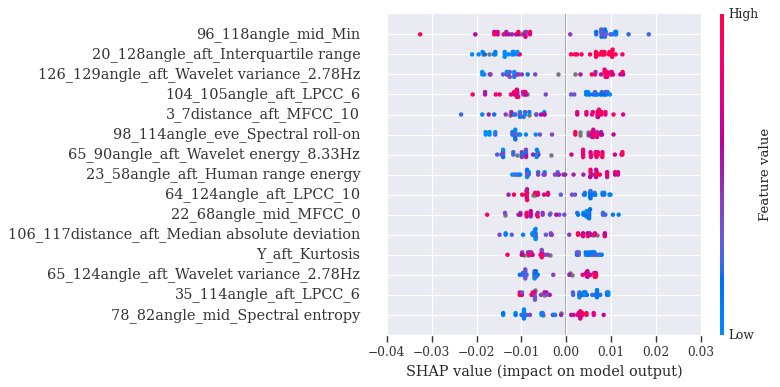

In [67]:
import matplotlib.pyplot
all_shap_values_concat = np.concatenate([sv for sv in list_shap_values])  # Use sv[1], sv[2], etc., for other classes

# Visualize SHAP values for all samples
shap.summary_plot(all_shap_values_concat, X_new, max_display=15, plot_size=[10,5], show=False)
matplotlib.pyplot.savefig("shap_combined_features_RF_patient_out_predict.pdf",dpi=700) #.png,.pdf will also support here

# Random Forest + SMOTE

In [73]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
param_grid = dict(n_estimators = [1, 2, 4, 8, 16, 32, 64, 100, 200], max_depth = np.linspace(1, 32, 32, endpoint=True).astype(int), min_samples_split = np.linspace(0.1, 1.0, 10, endpoint=True), min_samples_leaf = np.linspace(0.1, 0.5, 5, endpoint=True), max_features = list(range(1,100)), class_weight=['balanced'])


In [74]:
best_params = dict(n_estimators = 32, max_depth = 12, min_samples_split =  0.6, min_samples_leaf = 0.2, max_features = 2, class_weight = 'balanced')

In [75]:
model = RandomForestClassifier(**best_params, random_state = 42)

In [76]:
y_true_all = []
y_pred_all = []
y_pred_proba_all = []
cv = LeaveOneGroupOut()
list_shap_values = list()
list_test_sets = list()


# Manually iterate over each fold
for i, (train_idx, test_idx) in enumerate(cv.split(X_new, y, group)):
    X_train, X_test = X_new.loc[train_idx], X_new.loc[test_idx]
    y_train, y_test = y.loc[train_idx], y.loc[test_idx]
            
    #Replace nan values
            
    imp = SimpleImputer(missing_values=np.nan, strategy='mean')
    imp.fit(X_train)
    X_train = imp.transform(X_train)
    X_test = imp.transform(X_test)
    
    sm = SMOTE()
    X_train_oversampled, y_train_oversampled = sm.fit_resample(X_train, y_train)
            
            # Fit the pipeline on the training data (SMOTE is applied here)
    model.fit(X_train_oversampled, y_train_oversampled)
    
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    list_shap_values.append(shap_values[1])
     

            

    # Predict on the test data
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for AUC

    # Collect predictions and true labels
    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)
    y_pred_proba_all.extend(y_pred_proba)

# Compute metrics
auc_score = roc_auc_score(y_true_all, y_pred_proba_all)
precision = precision_score(y_true_all, y_pred_all)
recall = recall_score(y_true_all, y_pred_all)
f1 = f1_score(y_true_all, y_pred_all)
acc = accuracy_score(y_true_all, y_pred_all)
balanced_acc = balanced_accuracy_score(y_true_all, y_pred_all)

print(f'AUC: {auc_score}, Precision: {precision}, Recall: {recall}, F1-score: {f1}, Accuracy: {acc}, Balanced Accuracy: {balanced_acc}')

AUC: 1.0, Precision: 1.0, Recall: 1.0, F1-score: 1.0, Accuracy: 1.0, Balanced Accuracy: 1.0


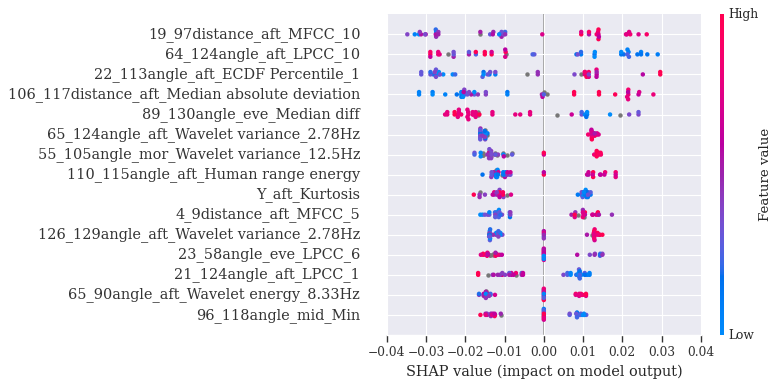

In [78]:
import matplotlib.pyplot
all_shap_values_concat = np.concatenate([sv for sv in list_shap_values])  # Use sv[1], sv[2], etc., for other classes

# Visualize SHAP values for all samples
shap.summary_plot(all_shap_values_concat, X_new, max_display=15, plot_size=[10,5], show=False)
matplotlib.pyplot.savefig("shap_combined_features_RF_smote_patient_out_predict.pdf",dpi=700) #.png,.pdf will also support here